# **Workflow Data Mining**

`Menerapkan Naive Bayes terhadap komentar chat live youtube untuk mengetahui apakah komentar tersebut masuk spam normal/promosi judi online`

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn untuk Modeling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Sastrawi untuk Preprocessing Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# nlp.id untuk lemmatizer Preprocessing teks indo
from nlp_id.lemmatizer import Lemmatizer 

# Import re untuk preprosessing karakter komentar
import re
# Untuk menyimpan model
import joblib

Preview Data:
              datetime           author_name  \
0  2024-10-07 08:32:03                KUSUMA   
1  2024-10-07 08:58:42            Tata PaNda   
2  2024-10-07 09:20:29  Nimas putri Paranata   
3  2024-10-07 09:30:23   proboyuwono djogdja   
4  2024-10-07 09:34:59    Vian Noorcha Putra   

                                             message  \
0                                 assalamu'alaikum..   
1                                  wa'alaikumussalam   
2                             udah lewat 22 menit ni   
3                                          16:30 wib   
4  Tribun Tv Mana Ini Kenapa Acaranya Belum Dimul...   

                                     cleaned_message  label  
0                                    assalamualaikum      0  
1                                   waalaikumussalam      0  
2                             udah lewat 22 menit ni      0  
3                                           1630 wib      0  
4  tribun tv mana ini kenapa acaranya belum dimul.

/tmp/ipykernel_7102/1022822775.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


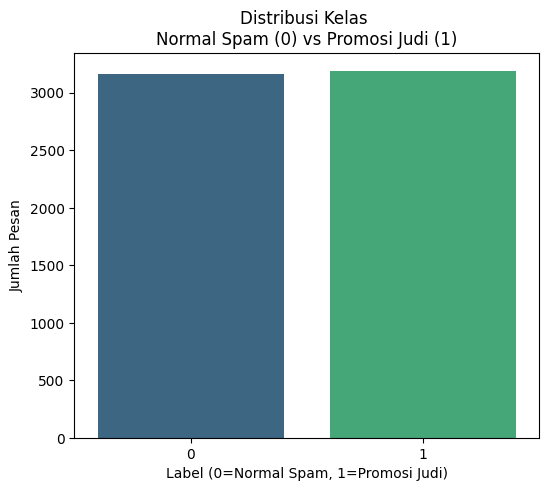

In [29]:
# Load data
df = pd.read_csv('../Datasets/youtube_chat_jogja_clean.csv')

# Tampilkan 5 data pertama
print("Preview Data:")
print(df.head())

# Cek distribusi label (Normal vs Spam)
print("\nDistribusi Label:")
print(df['label'].value_counts())

# Visualisasi Distribusi Label
plt.figure(figsize=(6,5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribusi Kelas \nNormal Spam (0) vs Promosi Judi (1)')
plt.xlabel('Label (0=Normal Spam, 1=Promosi Judi)')
plt.ylabel('Jumlah Pesan')
plt.show()

In [30]:
# Inisialisasi Sastrawi
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()
stemmer = StemmerFactory().create_stemmer()
lemmatizer = Lemmatizer()

def preprocess_text(text):

    # 1. Lowercase (Case Folding)
    text = text.lower()

    # 3. Cleansing Khusus (Hapus URL & Simbol, tapi SIMPAN Angka)
    # Menghapus link/URL yang sering ada di spam YouTube
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Menghapus tanda baca, tapi membiarkan huruf (a-z) dan angka (0-9)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 5. Hapus Stopword
    text = stopword.remove(text)

    # # 6. Stemming (opsional, bisa diaktifkan jika diperlukan)
    # text = stemmer.stem(text)

    # 7. Lemmatization (Opsional, bisa diaktifkan jika diperlukan) ==
    text = lemmatizer.lemmatize(text)

    # Menghapus spasi berlebih yang mungkin muncul setelah penghapusan
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan preprocessing pada kolom 'cleaned_message' 
# (Catatan: Jika 'cleaned_message' sudah sangat bersih, langkah ini bisa di-skip, 
# tapi disarankan tetap dijalankan untuk konsistensi pipeline)
df['text_processed'] = df['message'].fillna('').astype(str).apply(preprocess_text)

# Cek hasil preprocessing
print("\nContoh Hasil Preprocessing:")
print(df[['message', 'text_processed']].head())


Contoh Hasil Preprocessing:
                                             message  \
0                                 assalamu'alaikum..   
1                                  wa'alaikumussalam   
2                             udah lewat 22 menit ni   
3                                          16:30 wib   
4  Tribun Tv Mana Ini Kenapa Acaranya Belum Dimul...   

                                      text_processed  
0                                   assalamu alaikum  
1                                  wa alaikumussalam  
2                             udah lewat 22 menit ni  
3                                          16 30 wib  
4  tribun tv mana kenapa acara mulai wayang jogja...  


In [31]:
X = df['text_processed']  # Fitur (Teks)
y = df['label']           # Target (Label)

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

Jumlah Data Latih: 5080
Jumlah Data Uji: 1270


In [32]:
# Inisialisasi TF-IDF
vectorizer = TfidfVectorizer(max_features=5000) # Ambil 5000 fitur kata terbanyak

# Fit pada data latih, transform ke data latih & uji
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Bentuk Matriks Fitur Latih: {X_train_vec.shape}")

Bentuk Matriks Fitur Latih: (5080, 3157)


In [33]:
# 1. Multinomial Naive Bayes (Utama)
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# # 2. Logistic Regression (Pembanding)
# lr_model = LogisticRegression(max_iter=1000)
# lr_model.fit(X_train_vec, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!



--- Evaluasi Naive Bayes ---
Akurasi: 0.9630
Classification Report:
              precision    recall  f1-score   support

 Normal Spam       1.00      0.93      0.96       633
Promosi Judi       0.93      1.00      0.96       637

    accuracy                           0.96      1270
   macro avg       0.97      0.96      0.96      1270
weighted avg       0.97      0.96      0.96      1270



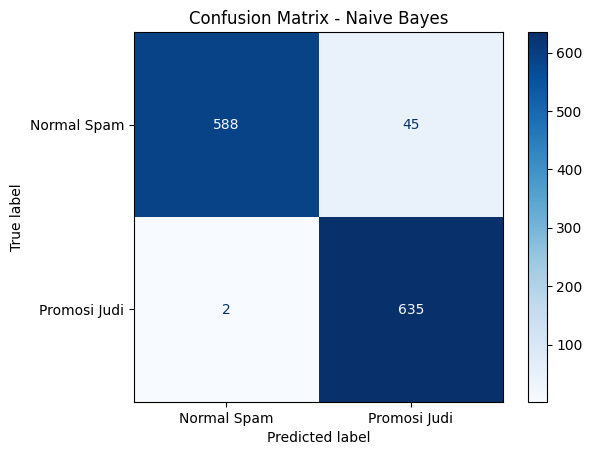

In [34]:
# Fungsi bantu evaluasi
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n--- Evaluasi {name} ---")
    print(f"Akurasi: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal Spam', 'Promosi Judi']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal Spam', 'Promosi Judi'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    return acc

# Evaluasi
acc_nb = evaluate_model(nb_model, "Naive Bayes", X_test_vec, y_test)
# acc_lr = evaluate_model(lr_model, "Logistic Regression", X_test_vec, y_test)

In [35]:
# Simulasi data baru (Nanti diganti dengan load csv 500 data)
# data_baru = pd.DataFrame({
#     'message': [
#         "info link gacor hari ini",
#         "selamat ulang tahun jogja istimewa",
#         "daftar dapat 100rb wisdomtoto",
#         "kapan mulainya min?"
#     ]
# })
data_baru = pd.read_csv('../Task/infer_live.csv')

# Preprocessing data baru (WAJIB SAMA dengan data latih)
data_baru['text_processed'] = data_baru['message'].fillna('').astype(str).apply(preprocess_text)

# Vectorisasi data baru (gunakan vectorizer yang sudah di-fit sebelumnya)
data_baru_vec = vectorizer.transform(data_baru['text_processed'])

# Prediksi
prediksi_nb = nb_model.predict(data_baru_vec)
probabilitas_nb = nb_model.predict_proba(data_baru_vec)

# Tampilkan Hasil
data_baru['Predik_Label'] = prediksi_nb
data_baru['Prob_Judi'] = probabilitas_nb[:, 1] # Probabilitas kelas 1

print("\nHasil Prediksi Data Baru:")
print(data_baru[['message', 'Predik_Label', 'Prob_Judi']])



Hasil Prediksi Data Baru:
                                               message  Predik_Label  \
0                                            @kanza.46             1   
1                                       @ZerinaVale-97             1   
2                                       @ZerinaVale-97             1   
3                                       @ZerinaVale-97             1   
4                                           @Suar_2612             1   
..                                                 ...           ...   
425                                Kaa furab apa rabun             0   
426                                    nama asli siapa             0   
427                      sound nya apa yang tadii kakk             0   
428  tapi lebih iconic bibir nya sih menurut aku pr...             0   
429                               nama asli kaka siapa             0   

     Prob_Judi  
0     0.501969  
1     0.501969  
2     0.501969  
3     0.501969  
4     0.501969  
..    

20 Kata Kunci Teratas pada Pesan Promosi Judi Online:
fire         -2.189780
wisdomtoto   -2.246577
100rb        -2.610882
google       -2.663003
ketik        -2.664351
freebet      -2.925963
gratis       -3.211006
gacor        -4.215901
slot         -4.329739
buru         -5.111738
gas          -5.119051
pas4d        -5.341128
star         -5.368688
bwtogel      -6.123463
gacorr       -6.135403
maxwin       -6.428961
cuan         -6.518194
daftar       -6.716382
gampang      -6.793950
main         -6.793950
dtype: float64


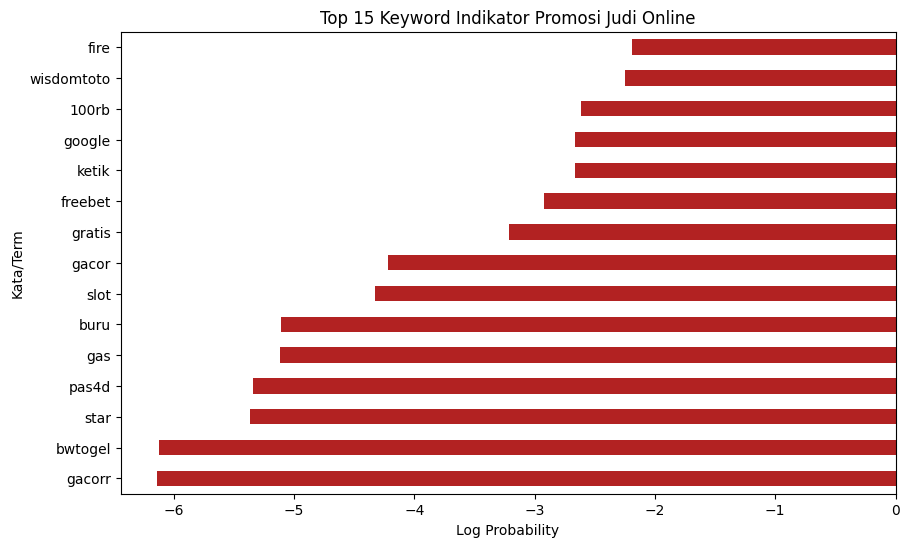

In [36]:
# 1. Ambil semua fitur (kata-kata) dari vectorizer
feature_names = vectorizer.get_feature_names_out()

# 2. Ambil log probabilitas fitur untuk setiap kelas
# Biasanya: index 0 = Normal, index 1 = Promosi Judi (sesuaikan dengan label Anda)
prob_judi = nb_model.feature_log_prob_[1] 

# 3. Gabungkan nama kata dengan nilai probabilitasnya
top_words_judi = pd.Series(prob_judi, index=feature_names).sort_values(ascending=False)

# 4. Tampilkan 20 kata kunci teratas yang mengindikasikan Promosi Judi
print("20 Kata Kunci Teratas pada Pesan Promosi Judi Online:")
print(top_words_judi.head(20))

# 5. Opsional: Visualisasi dengan Bar Chart agar bagus untuk Artikel
plt.figure(figsize=(10, 6))
top_words_judi.head(15).plot(kind='barh', color='firebrick').invert_yaxis()
plt.title('Top 15 Keyword Indikator Promosi Judi Online')
plt.xlabel('Log Probability')
plt.ylabel('Kata/Term')
plt.show()

# **Ini Untuk Ekspor Model Naive Bayes (Sama format Vector nya)**
`Siapa tau nanti mau dipakai sebagai fitur di sebuah aplikasi`

In [37]:
# # Simpan model dan vectorizer
# joblib.dump(nb_model, 'model_naive_bayes.pkl')
# joblib.dump(vectorizer, 'vectorizer_tfidf.pkl')

# print("Model dan Vectorizer berhasil disimpan!")